## Exploração

In [1]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import sys
sys.path.append('../src')

from data_loader import processar_corrida, plotar_estrategia, plotar_degradacao, ultrapassagens_estrategia

In [2]:
session = fastf1.get_session(2025, 'Bahrein', 'R')
session.load()

events      WARNING 	Correcting user input 'Bahrein' to 'Bahrain Grand Prix'
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5'

In [3]:
session.laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:57:13.827000,PIA,81,0 days 00:01:38.693000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.130000,...,False,McLaren,0 days 00:55:34.907000,2025-04-13 15:03:49.174,1,1.0,False,,False,False
1,0 days 00:58:51.319000,PIA,81,0 days 00:01:37.492000,2.0,1.0,NaT,NaT,0 days 00:00:31.139000,0 days 00:00:42.343000,...,False,McLaren,0 days 00:57:13.827000,2025-04-13 15:05:28.094,1,1.0,False,,False,True
2,0 days 01:00:29.402000,PIA,81,0 days 00:01:38.083000,3.0,1.0,NaT,NaT,0 days 00:00:31.306000,0 days 00:00:42.727000,...,False,McLaren,0 days 00:58:51.319000,2025-04-13 15:07:05.586,1,1.0,False,,False,True
3,0 days 01:02:07.535000,PIA,81,0 days 00:01:38.133000,4.0,1.0,NaT,NaT,0 days 00:00:31.326000,0 days 00:00:42.796000,...,False,McLaren,0 days 01:00:29.402000,2025-04-13 15:08:43.669,1,1.0,False,,False,True
4,0 days 01:03:45.578000,PIA,81,0 days 00:01:38.043000,5.0,1.0,NaT,NaT,0 days 00:00:31.305000,0 days 00:00:42.690000,...,False,McLaren,0 days 01:02:07.535000,2025-04-13 15:10:21.802,1,1.0,False,,False,True


In [4]:
ham = session.laps.pick_drivers('HAM')
ham[['LapNumber', 'Stint', 'Compound', 'PitInTime', 'PitOutTime']]

,LapNumber,Stint,Compound,PitInTime,PitOutTime
228,1.0,1.0,MEDIUM,NaT,NaT
229,2.0,1.0,MEDIUM,NaT,NaT
230,3.0,1.0,MEDIUM,NaT,NaT
231,4.0,1.0,MEDIUM,NaT,NaT
232,5.0,1.0,MEDIUM,NaT,NaT
233,6.0,1.0,MEDIUM,NaT,NaT
234,7.0,1.0,MEDIUM,NaT,NaT
235,8.0,1.0,MEDIUM,NaT,NaT
236,9.0,1.0,MEDIUM,NaT,NaT
237,10.0,1.0,MEDIUM,NaT,NaT


In [5]:
session.laps.groupby(['Driver', 'Stint', 'Compound']).size()

Driver  Stint  Compound
ALB     1.0    SOFT        16
        2.0    HARD        16
        3.0    MEDIUM      25
ALO     1.0    MEDIUM      16
        2.0    MEDIUM      16
                           ..
TSU     2.0    MEDIUM      21
        3.0    SOFT        25
VER     1.0    SOFT        10
        2.0    HARD        16
        3.0    MEDIUM      31
Length: 62, dtype: int64

In [6]:
resumo_stints = session.laps.groupby(['Driver', 'Stint', 'Compound']).size().reset_index(name='Voltas')
resumo_stints.head()

,Driver,Stint,Compound,Voltas
0,ALB,1.0,SOFT,16
1,ALB,2.0,HARD,16
2,ALB,3.0,MEDIUM,25
3,ALO,1.0,MEDIUM,16
4,ALO,2.0,MEDIUM,16


In [7]:
resumo_stints['Inicio'] = resumo_stints.groupby('Driver')['Voltas'].cumsum() - resumo_stints['Voltas']
resumo_stints.head()

,Driver,Stint,Compound,Voltas,Inicio
0,ALB,1.0,SOFT,16,0
1,ALB,2.0,HARD,16,16
2,ALB,3.0,MEDIUM,25,32
3,ALO,1.0,MEDIUM,16,0
4,ALO,2.0,MEDIUM,16,16


In [8]:
cores = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'lightgray', 'INTERMEDIATE': 'green', 'WET': 'blue'}
resumo_stints['Cor'] = resumo_stints['Compound'].map(cores)
resumo_stints.head()

,Driver,Stint,Compound,Voltas,Inicio,Cor
0,ALB,1.0,SOFT,16,0,red
1,ALB,2.0,HARD,16,16,lightgray
2,ALB,3.0,MEDIUM,25,32,gold
3,ALO,1.0,MEDIUM,16,0,gold
4,ALO,2.0,MEDIUM,16,16,gold


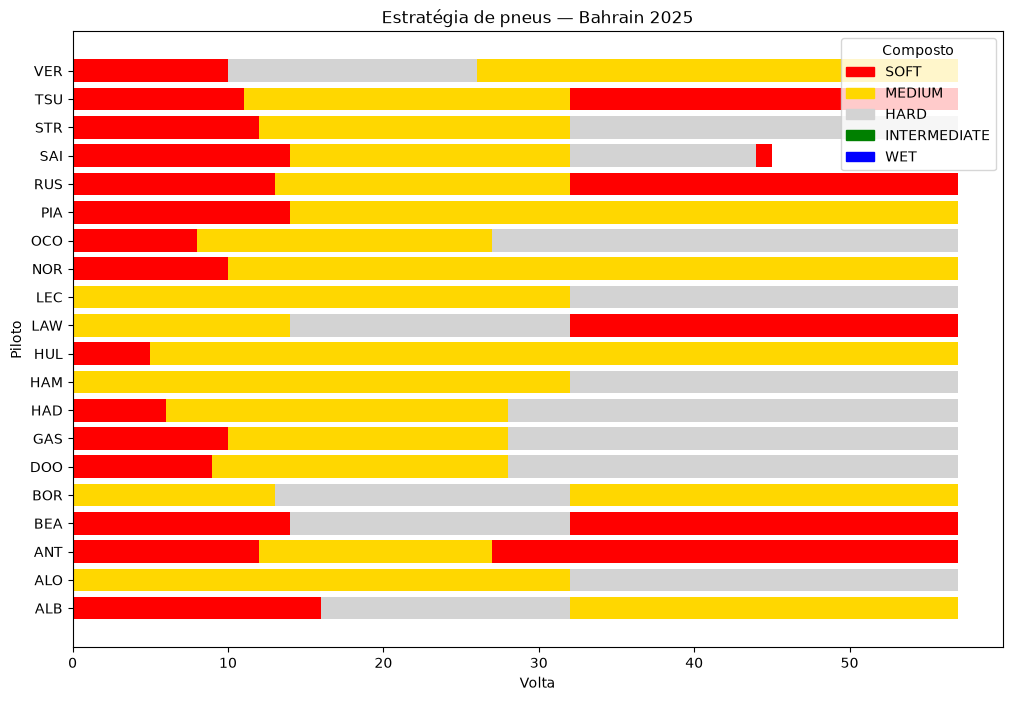

In [9]:
plt.figure(figsize=(12, 8))
plt.barh(y=resumo_stints['Driver'], width=resumo_stints['Voltas'], left=resumo_stints['Inicio'], color=resumo_stints['Cor'])
plt.xlabel('Volta')
plt.ylabel('Piloto')
plt.title('Estratégia de pneus — Bahrain 2025')
legenda = []
for composto, cor in cores.items():
    legenda.append(Patch(color=cor, label=composto))

plt.legend(handles=legenda, title='Composto')
plt.savefig('../reports/figures/estrategia_pneus_bahrain2025.png')
plt.show()

In [10]:
session.laps['LapTime'].dt.total_seconds()

0       98.693
1       97.492
2       98.083
3       98.133
4       98.043
         ...  
1123    98.260
1124    98.498
1125    98.424
1126    98.998
1127    98.823
Name: LapTime, Length: 1128, dtype: float64

In [11]:
session.laps['VoltaNoStint'] = session.laps.groupby(['Driver', 'Stint']).cumcount() + 1
session.laps[session.laps['Driver'] == 'HAM']

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,VoltaNoStint
228,0 days 00:57:19.702000,HAM,44,0 days 00:01:44.568000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:44.052000,...,Ferrari,0 days 00:55:34.907000,2025-04-13 15:03:49.174,1,9.0,False,,False,False,1
229,0 days 00:58:58.268000,HAM,44,0 days 00:01:38.566000,2.0,1.0,NaT,NaT,0 days 00:00:31.329000,0 days 00:00:42.931000,...,Ferrari,0 days 00:57:19.702000,2025-04-13 15:05:33.969,1,9.0,False,,False,True,2
230,0 days 01:00:36.687000,HAM,44,0 days 00:01:38.419000,3.0,1.0,NaT,NaT,0 days 00:00:31.073000,0 days 00:00:43.067000,...,Ferrari,0 days 00:58:58.268000,2025-04-13 15:07:12.535,1,9.0,False,,False,True,3
231,0 days 01:02:15.341000,HAM,44,0 days 00:01:38.654000,4.0,1.0,NaT,NaT,0 days 00:00:31.030000,0 days 00:00:43.265000,...,Ferrari,0 days 01:00:36.687000,2025-04-13 15:08:50.954,1,9.0,False,,False,True,4
232,0 days 01:03:54.806000,HAM,44,0 days 00:01:39.465000,5.0,1.0,NaT,NaT,0 days 00:00:31.108000,0 days 00:00:43.969000,...,Ferrari,0 days 01:02:15.341000,2025-04-13 15:10:29.608,1,9.0,False,,False,True,5
233,0 days 01:05:33.910000,HAM,44,0 days 00:01:39.104000,6.0,1.0,NaT,NaT,0 days 00:00:31.357000,0 days 00:00:43.341000,...,Ferrari,0 days 01:03:54.806000,2025-04-13 15:12:09.073,1,9.0,False,,False,True,6
234,0 days 01:07:13.189000,HAM,44,0 days 00:01:39.279000,7.0,1.0,NaT,NaT,0 days 00:00:31.332000,0 days 00:00:43.404000,...,Ferrari,0 days 01:05:33.910000,2025-04-13 15:13:48.177,1,9.0,False,,False,True,7
235,0 days 01:08:52.932000,HAM,44,0 days 00:01:39.743000,8.0,1.0,NaT,NaT,0 days 00:00:31.451000,0 days 00:00:43.679000,...,Ferrari,0 days 01:07:13.189000,2025-04-13 15:15:27.456,1,9.0,False,,False,True,8
236,0 days 01:10:33.877000,HAM,44,0 days 00:01:40.945000,9.0,1.0,NaT,NaT,0 days 00:00:31.727000,0 days 00:00:44.660000,...,Ferrari,0 days 01:08:52.932000,2025-04-13 15:17:07.199,1,8.0,False,,False,True,9
237,0 days 01:12:13.174000,HAM,44,0 days 00:01:39.297000,10.0,1.0,NaT,NaT,0 days 00:00:31.567000,0 days 00:00:43.314000,...,Ferrari,0 days 01:10:33.877000,2025-04-13 15:18:48.144,1,8.0,False,,False,True,10


In [12]:
session.laps['LapTimeSeconds'] = session.laps['LapTime'].dt.total_seconds()
voltas_piloto = session.laps[session.laps['Driver'] == 'HAM']
voltas_piloto.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,VoltaNoStint,LapTimeSeconds
228,0 days 00:57:19.702000,HAM,44,0 days 00:01:44.568000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:44.052000,...,0 days 00:55:34.907000,2025-04-13 15:03:49.174,1,9.0,False,,False,False,1,104.568
229,0 days 00:58:58.268000,HAM,44,0 days 00:01:38.566000,2.0,1.0,NaT,NaT,0 days 00:00:31.329000,0 days 00:00:42.931000,...,0 days 00:57:19.702000,2025-04-13 15:05:33.969,1,9.0,False,,False,True,2,98.566
230,0 days 01:00:36.687000,HAM,44,0 days 00:01:38.419000,3.0,1.0,NaT,NaT,0 days 00:00:31.073000,0 days 00:00:43.067000,...,0 days 00:58:58.268000,2025-04-13 15:07:12.535,1,9.0,False,,False,True,3,98.419
231,0 days 01:02:15.341000,HAM,44,0 days 00:01:38.654000,4.0,1.0,NaT,NaT,0 days 00:00:31.030000,0 days 00:00:43.265000,...,0 days 01:00:36.687000,2025-04-13 15:08:50.954,1,9.0,False,,False,True,4,98.654
232,0 days 01:03:54.806000,HAM,44,0 days 00:01:39.465000,5.0,1.0,NaT,NaT,0 days 00:00:31.108000,0 days 00:00:43.969000,...,0 days 01:02:15.341000,2025-04-13 15:10:29.608,1,9.0,False,,False,True,5,99.465


In [13]:
stint1 = voltas_piloto[voltas_piloto['Stint'] == 1]
stint1[['VoltaNoStint', 'LapTimeSeconds']]

,VoltaNoStint,LapTimeSeconds
228,1,104.568
229,2,98.566
230,3,98.419
231,4,98.654
232,5,99.465
233,6,99.104
234,7,99.279
235,8,99.743
236,9,100.945
237,10,99.297


In [14]:
len(stint1)

17

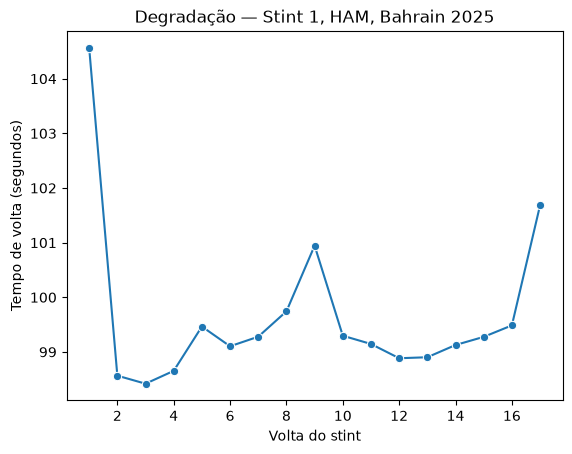

In [15]:
sns.lineplot(data=stint1, x='VoltaNoStint', y='LapTimeSeconds', marker='o')
plt.xlabel('Volta do stint')
plt.ylabel('Tempo de volta (segundos)')
plt.title('Degradação — Stint 1, HAM, Bahrain 2025')
plt.show()

In [16]:
session.laps[session.laps['LapNumber'] == 9][['Driver', 'LapTimeSeconds', 'TrackStatus']]

,Driver,LapTimeSeconds,TrackStatus
8,PIA,98.800,1
65,RUS,98.900,1
122,NOR,99.104,1
179,LEC,99.164,1
236,HAM,100.945,1
293,VER,99.670,1
350,GAS,100.096,1
407,OCO,117.716,1
464,TSU,100.727,1
521,BEA,100.284,1


A volta 9 do Stint 1 aparece como outlier no gráfico de degradação, mas não foi por causa do pneu — checando o TrackStatus (pista livre) e cruzando com notícias da corrida, foi uma disputa de posição entre pilotos naquela volta. Por isso, outliers no gráfico de degradação precisam ser investigados antes de virar conclusão — nem todo pico é o pneu "acabando".

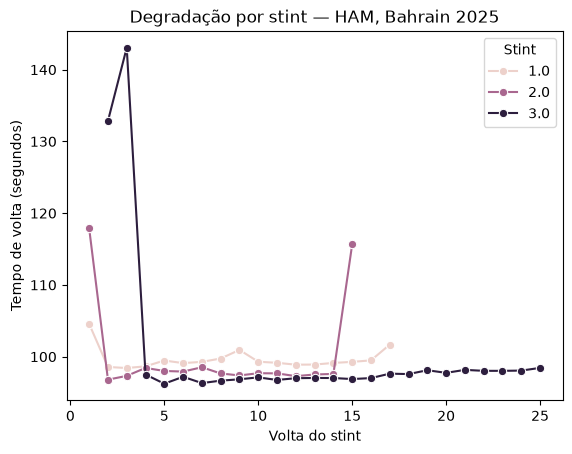

In [17]:
sns.lineplot(data=voltas_piloto, x='VoltaNoStint', y='LapTimeSeconds', hue='Stint', marker='o')
plt.xlabel('Volta do stint')
plt.ylabel('Tempo de volta (segundos)')
plt.title('Degradação por stint — HAM, Bahrain 2025')
plt.show()

O tempo de volta bruto fica mais estável do que o esperado ao longo do stint, mesmo com o pneu degradando — provável efeito do combustível: o carro fica mais leve ao longo da corrida (menos combustível = mais rápido), o que compensa parte da perda de performance do pneu. Análise futura poderia isolar o efeito puro do pneu corrigindo pelo combustível ("fuel-corrected lap time").

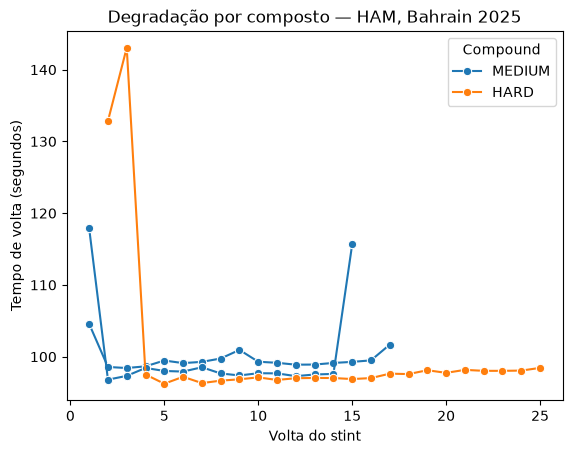

In [18]:
sns.lineplot(data=voltas_piloto, x='VoltaNoStint', y='LapTimeSeconds', hue='Compound', units='Stint', estimator=None, marker='o')
plt.xlabel('Volta do stint')
plt.ylabel('Tempo de volta (segundos)')
plt.title('Degradação por composto — HAM, Bahrain 2025')
plt.savefig('../reports/figures/degradacao_composto.png')
plt.show()

In [19]:
resumo_stints[resumo_stints['Driver'] == 'HAM']

,Driver,Stint,Compound,Voltas,Inicio,Cor
25,HAM,1.0,MEDIUM,17,0,gold
26,HAM,2.0,MEDIUM,15,17,gold
27,HAM,3.0,HARD,25,32,lightgray


In [20]:
voltas_piloto.groupby('Stint')['LapTimeSeconds'].median()

Stint
1.0    99.276
2.0    97.674
3.0    97.356
Name: LapTimeSeconds, dtype: float64

A mediana do tempo de volta cai a cada stint (99.28s → 97.67s → 97.36s), seguindo a ordem cronológica da corrida — reforça o efeito de combustível (carro mais leve com o passar da corrida) como um fator forte no tempo de volta bruto, possivelmente mais forte que o composto de pneu nesse exemplo.

## Estratégia Stint + Pneus -> realização de função repetitiva

In [21]:
aus = processar_corrida(2025, 1)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
logger      WARNING 	Failed to add first lap time from Ergast!
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	No cached data found for car_data. Loading 

In [22]:
aus.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds,VoltaNoStint,Ano,GP
0,0 days 01:13:00.002000,VER,1,NaT,1.0,1.0,NaT,NaT,NaT,0 days 00:00:20.705000,...,124,2.0,False,,False,False,NaN,1,2025,Australian Grand Prix
1,0 days 01:15:49.358000,VER,1,NaT,2.0,1.0,NaT,0 days 01:15:38.205000,0 days 00:00:58.141000,0 days 00:00:37.976000,...,4,2.0,False,,False,False,NaN,2,2025,Australian Grand Prix
2,0 days 01:18:31.526000,VER,1,NaT,3.0,2.0,0 days 01:15:51.658000,0 days 01:18:20.223000,0 days 00:00:56.230000,0 days 00:00:33.683000,...,4,2.0,False,,False,False,NaN,1,2025,Australian Grand Prix
3,0 days 01:21:07.226000,VER,1,NaT,4.0,3.0,0 days 01:18:34.029000,0 days 01:20:56.543000,0 days 00:00:54.351000,0 days 00:00:32.712000,...,4,2.0,False,,False,False,NaN,1,2025,Australian Grand Prix
4,0 days 01:23:30.835000,VER,1,0 days 00:02:23.609000,5.0,4.0,0 days 01:21:09.534000,NaT,0 days 00:00:53.513000,0 days 00:00:32.627000,...,4,2.0,False,,False,False,143.609,1,2025,Australian Grand Prix


In [23]:
calendario = fastf1.get_event_schedule(2025)
calendario[['RoundNumber', 'EventName', 'Country', 'EventDate']]

,RoundNumber,EventName,Country,EventDate
0,0,Pre-Season Testing,Bahrain,2025-02-28
1,1,Australian Grand Prix,Australia,2025-03-16
2,2,Chinese Grand Prix,China,2025-03-23
3,3,Japanese Grand Prix,Japan,2025-04-06
4,4,Bahrain Grand Prix,Bahrain,2025-04-13
5,5,Saudi Arabian Grand Prix,Saudi Arabia,2025-04-20
6,6,Miami Grand Prix,United States,2025-05-04
7,7,Emilia Romagna Grand Prix,Italy,2025-05-18
8,8,Monaco Grand Prix,Monaco,2025-05-25
9,9,Spanish Grand Prix,Spain,2025-06-01


In [24]:
corridas = calendario[calendario['RoundNumber'] > 0]
corridas[['RoundNumber', 'EventName']]

,RoundNumber,EventName
1,1,Australian Grand Prix
2,2,Chinese Grand Prix
3,3,Japanese Grand Prix
4,4,Bahrain Grand Prix
5,5,Saudi Arabian Grand Prix
6,6,Miami Grand Prix
7,7,Emilia Romagna Grand Prix
8,8,Monaco Grand Prix
9,9,Spanish Grand Prix
10,10,Canadian Grand Prix


In [25]:
tabelas = []
falhas = []

for rodada in corridas['RoundNumber']:
    try:
         tabela = processar_corrida(2025, rodada)
         tabelas.append(tabela)
    except Exception as e:
        print(f"Falha na rodada {rodada}: {e}")
        falhas.append(rodada)

len(tabelas), falhas

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INF

(24, [])

In [26]:
corridas_2025 = pd.concat(tabelas, ignore_index=True)
corridas_2025.shape

(26690, 35)

In [27]:
corridas_2025.to_csv('../data/processed/corridas_2025.csv', index=False)

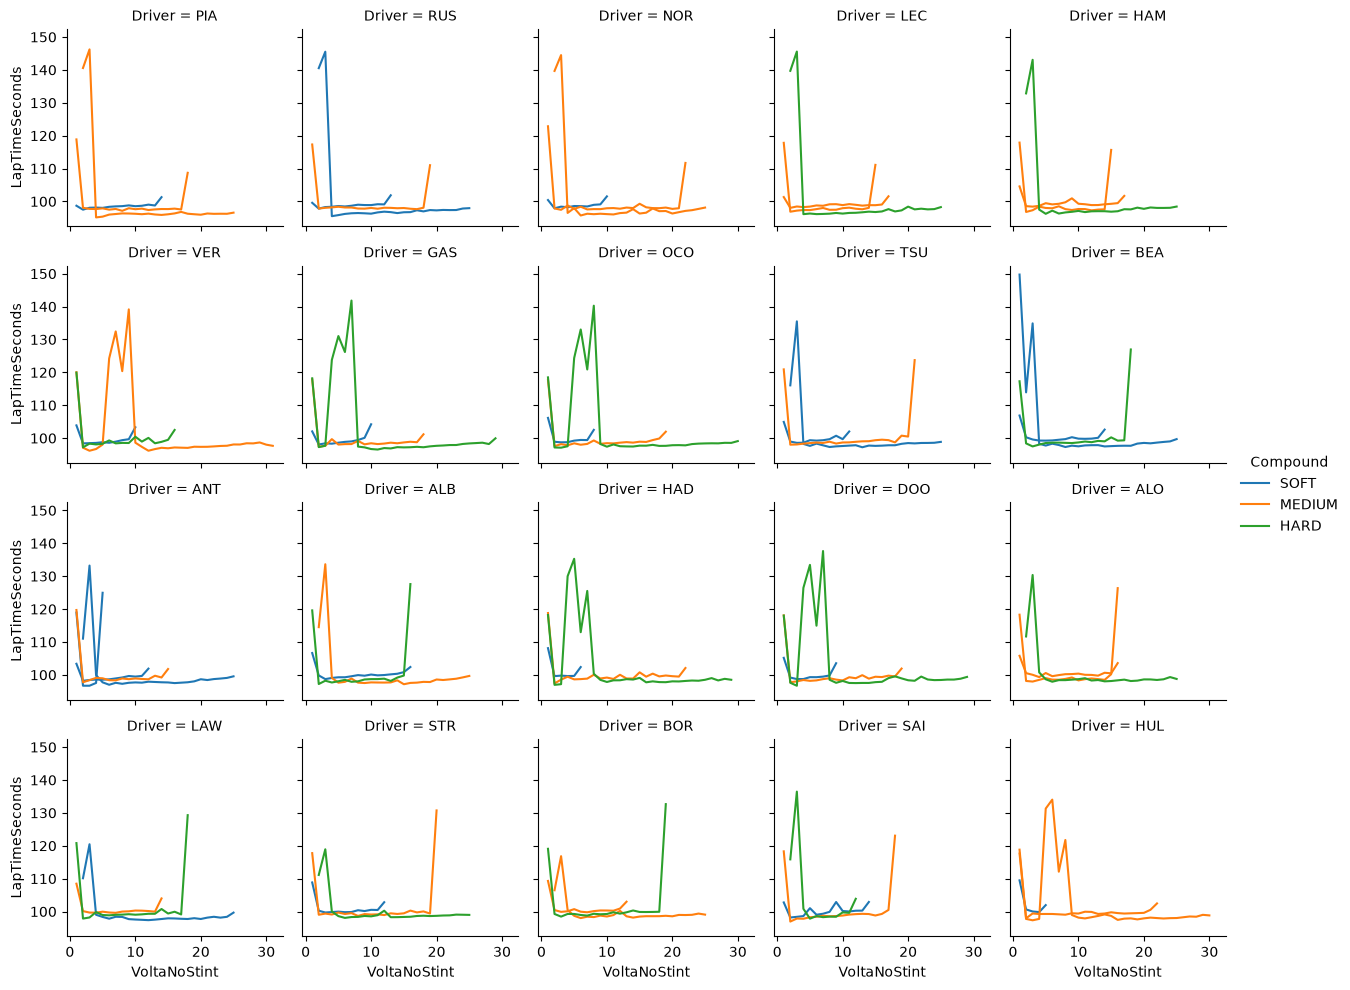

In [28]:
sns.relplot(
    data=session.laps,
    x='VoltaNoStint', y='LapTimeSeconds',
    hue='Compound', units='Stint', estimator=None,
    col='Driver', col_wrap=5,
    kind='line', height=2.5
)

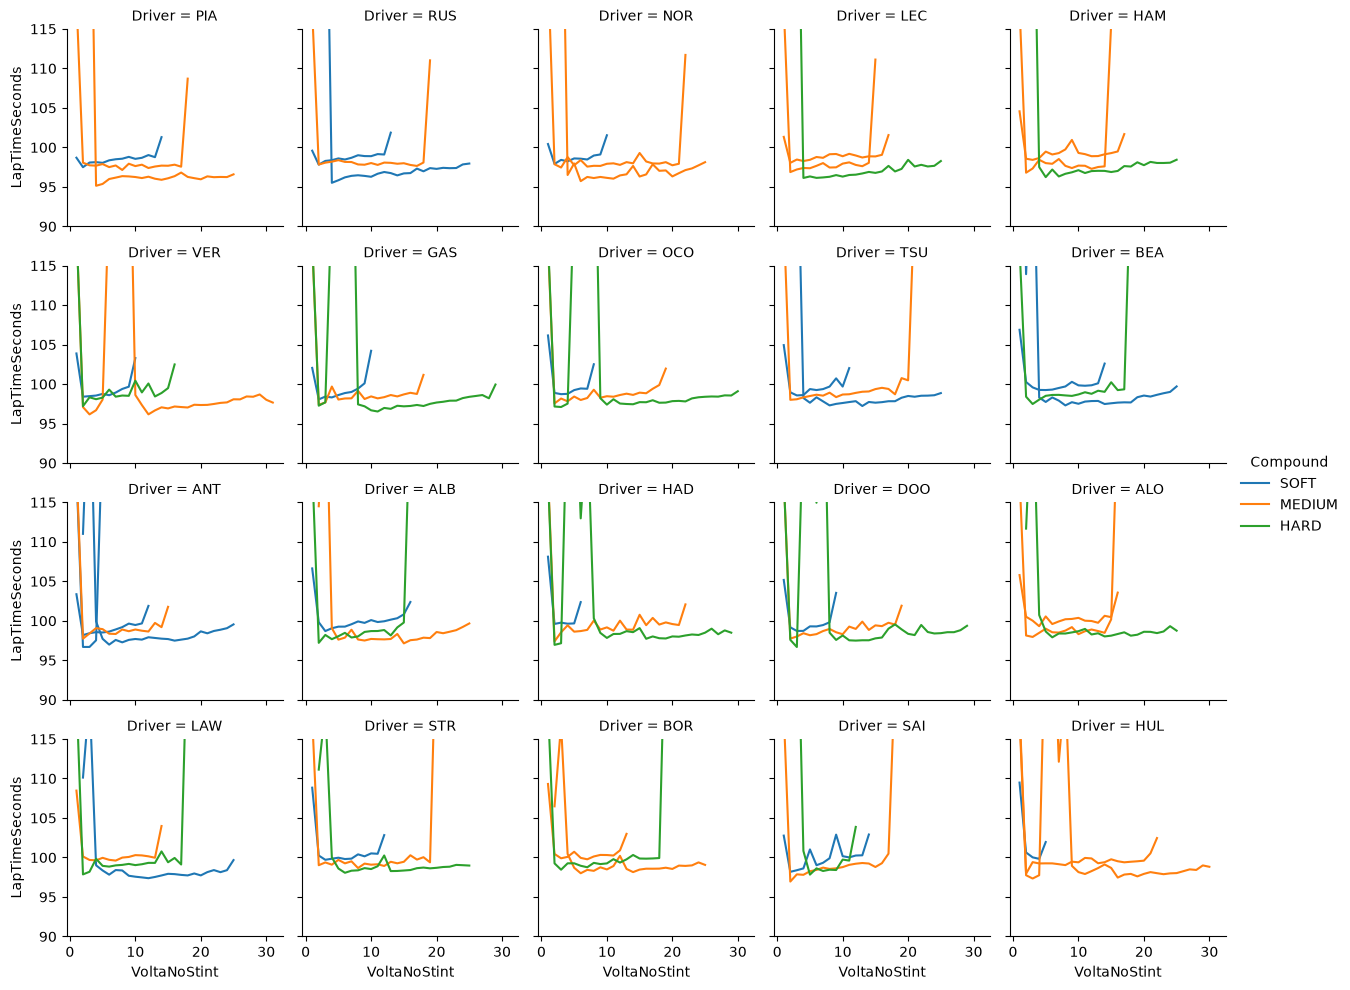

In [29]:
grade = sns.relplot(
    data=session.laps,
    x='VoltaNoStint', y='LapTimeSeconds',
    hue='Compound', units='Stint', estimator=None,
    col='Driver', col_wrap=5,
    kind='line', height=2.5
)
grade.set(ylim=(90, 115))

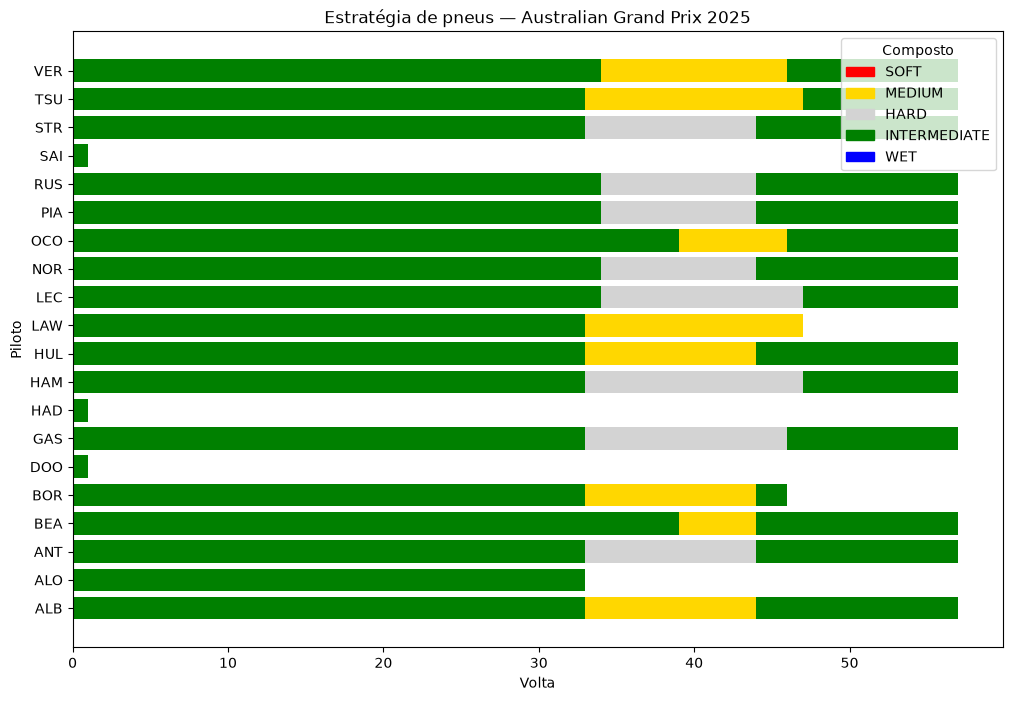

In [30]:
teste2 = corridas_2025[corridas_2025['GP'] == 'Australian Grand Prix']
plotar_estrategia(teste2)

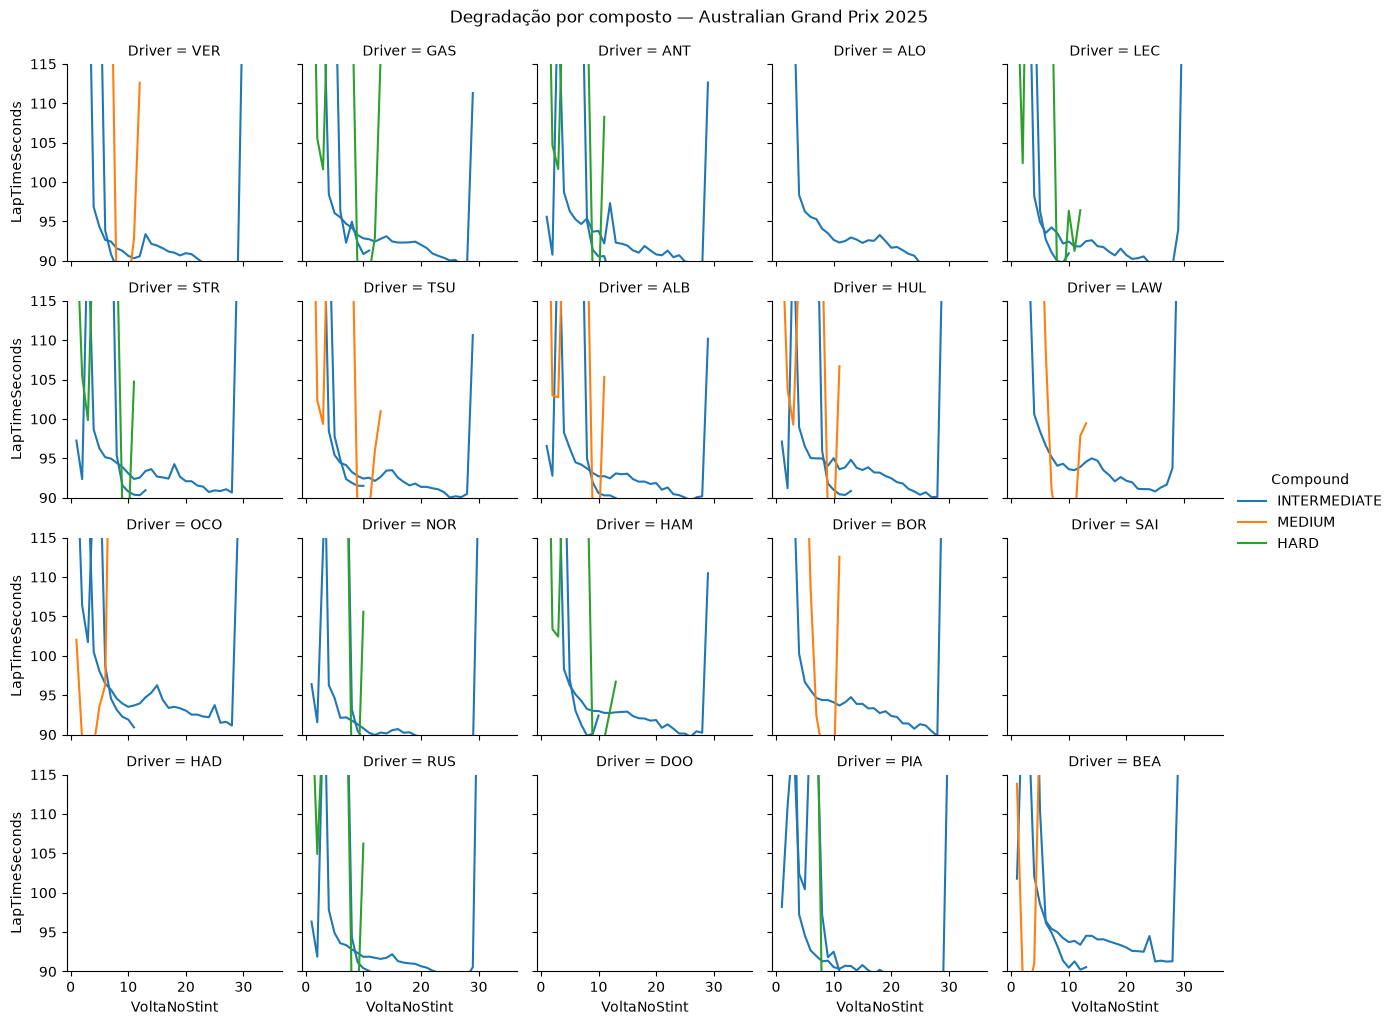

In [31]:
plotar_degradacao(teste2)

## Ultrapassagens

In [32]:
session.laps[session.laps['Driver'] == 'HAM'][['LapNumber', 'Position']]

,LapNumber,Position
228,1.0,9.0
229,2.0,9.0
230,3.0,9.0
231,4.0,9.0
232,5.0,9.0
233,6.0,9.0
234,7.0,9.0
235,8.0,9.0
236,9.0,8.0
237,10.0,8.0


In [33]:
ham_laps = session.laps[session.laps['Driver'] == 'HAM'].sort_values('LapNumber')
ham_laps['MudancaPosicao'] = ham_laps['Position'].diff()
ham_laps[['LapNumber', 'Position', 'MudancaPosicao']]

,LapNumber,Position,MudancaPosicao
228,1.0,9.0,NaN
229,2.0,9.0,0.0
230,3.0,9.0,0.0
231,4.0,9.0,0.0
232,5.0,9.0,0.0
233,6.0,9.0,0.0
234,7.0,9.0,0.0
235,8.0,9.0,0.0
236,9.0,8.0,-1.0
237,10.0,8.0,0.0


`.diff()` -> negativo = ganhou posição (número caiu), positivo = perdeu posição (número subiu), zero = ficou igual.

In [34]:
ham_laps[['LapNumber', 'Position', 'MudancaPosicao', 'PitInTime', 'PitOutTime']]

,LapNumber,Position,MudancaPosicao,PitInTime,PitOutTime
228,1.0,9.0,NaN,NaT,NaT
229,2.0,9.0,0.0,NaT,NaT
230,3.0,9.0,0.0,NaT,NaT
231,4.0,9.0,0.0,NaT,NaT
232,5.0,9.0,0.0,NaT,NaT
233,6.0,9.0,0.0,NaT,NaT
234,7.0,9.0,0.0,NaT,NaT
235,8.0,9.0,0.0,NaT,NaT
236,9.0,8.0,-1.0,NaT,NaT
237,10.0,8.0,0.0,NaT,NaT


In [35]:
pit_lap = ham_laps['PitInTime'].notna() | ham_laps['PitOutTime'].notna()
ham_laps['VoltaDePit'] = pit_lap
ham_laps[['LapNumber', 'MudancaPosicao', 'VoltaDePit']]

,LapNumber,MudancaPosicao,VoltaDePit
228,1.0,NaN,False
229,2.0,0.0,False
230,3.0,0.0,False
231,4.0,0.0,False
232,5.0,0.0,False
233,6.0,0.0,False
234,7.0,0.0,False
235,8.0,0.0,False
236,9.0,-1.0,False
237,10.0,0.0,False


In [36]:
ham_laps[~ham_laps['VoltaDePit']][['LapNumber', 'MudancaPosicao']]

,LapNumber,MudancaPosicao
228,1.0,NaN
229,2.0,0.0
230,3.0,0.0
231,4.0,0.0
232,5.0,0.0
233,6.0,0.0
234,7.0,0.0
235,8.0,0.0
236,9.0,-1.0
237,10.0,0.0


In [37]:
ham_laps['MudancaPosicao'].sum()

np.float64(-4.0)

In [38]:
laps_ordenadas = session.laps.sort_values(['Driver', 'LapNumber'])
laps_ordenadas['MudancaPosicao'] = laps_ordenadas.groupby('Driver')['Position'].diff()

In [39]:
laps_ordenadas[laps_ordenadas['Driver'] == 'HAM']['MudancaPosicao'].sum()

np.float64(-4.0)

In [40]:
laps_ordenadas['VoltaDePit'] = laps_ordenadas['PitInTime'].notna() | laps_ordenadas['PitOutTime'].notna()

ultrapassagens_reais = laps_ordenadas[~laps_ordenadas['VoltaDePit']].groupby('Driver')['MudancaPosicao'].sum()
ultrapassagens_reais.sort_values()

Driver
VER   -22.0
OCO   -18.0
BEA   -18.0
ALB   -18.0
TSU   -15.0
LAW   -15.0
ANT   -15.0
GAS   -13.0
HAM   -13.0
DOO   -12.0
NOR   -11.0
STR   -11.0
BOR   -10.0
HAD    -9.0
ALO    -9.0
HUL    -8.0
SAI    -5.0
RUS    -4.0
LEC    -3.0
PIA    -2.0
Name: MudancaPosicao, dtype: float64

In [41]:
laps_ordenadas[(laps_ordenadas['Driver'] == 'VER') & (~laps_ordenadas['VoltaDePit'])][['LapNumber', 'Position', 'MudancaPosicao']]

,LapNumber,Position,MudancaPosicao
285,1.0,8.0,NaN
286,2.0,8.0,0.0
287,3.0,8.0,0.0
288,4.0,8.0,0.0
289,5.0,7.0,-1.0
290,6.0,7.0,0.0
291,7.0,7.0,0.0
292,8.0,7.0,0.0
293,9.0,7.0,0.0
296,12.0,16.0,-1.0


In [42]:
ver = laps_ordenadas[(laps_ordenadas['Driver'] == 'VER') & (~laps_ordenadas['VoltaDePit'])]
ver[['LapNumber', 'Position', 'MudancaPosicao']].sort_values('MudancaPosicao')

,LapNumber,Position,MudancaPosicao
317,33.0,8.0,-5.0
313,29.0,14.0,-3.0
297,13.0,13.0,-3.0
312,28.0,17.0,-2.0
299,15.0,10.0,-2.0
341,57.0,6.0,-1.0
316,32.0,13.0,-1.0
302,18.0,7.0,-1.0
301,17.0,8.0,-1.0
300,16.0,9.0,-1.0


In [43]:
ver_total = laps_ordenadas[laps_ordenadas['Driver'] == 'VER']
ver_total['MudancaPosicao'].sum()

np.float64(-2.0)

In [44]:
ver_total[ver_total['VoltaDePit']][['LapNumber', 'Position', 'MudancaPosicao']]

,LapNumber,Position,MudancaPosicao
294,10.0,7.0,0.0
295,11.0,17.0,10.0
310,26.0,11.0,2.0
311,27.0,19.0,8.0


Criação da função -> tabela

In [45]:
teste2 = corridas_2025[corridas_2025['GP'] == 'Australian Grand Prix']
ultrapassagens_estrategia(teste2)

Ultrapassagens reais  \
GP                    Driver                         
Australian Grand Prix ALB                     -4.0   
                      ALO                      0.0   
                      ANT                     -9.0   
                      BEA                     -4.0   
                      BOR                      0.0   
                      DOO                      0.0   
                      GAS                     -2.0   
                      HAD                      0.0   
                      HAM                     -6.0   
                      HUL                     -4.0   
                      LAW                     -8.0   
                      LEC                     -5.0   
                      NOR                     -5.0   
                      OCO                     -1.0   
                      PIA                     -7.0   
                      RUS                     -5.0   
                      SAI                      0.0   
                      STR                     -3.0   
                      TSU                     -1.0   
                      VER                     -1.0   

                              Mudancas de posicao (pitstop)  \
GP                    Driver                                  
Australian Grand Prix ALB                               2.0   
                      ALO                               0.0   
                      ANT                               0.0   
                      BEA                               1.0   
                      BOR                              -1.0   
                      DOO                               NaN   
                      GAS                               4.0   
                      HAD                               NaN   
                      HAM                               8.0   
                      HUL                              -1.0   
                      LAW                               1.0   
                      LEC                               8.0   
                      NOR                               5.0   
                      OCO                              -1.0   
                      PIA                              13.0   
                      RUS                               4.0   
                      SAI                               NaN   
                      STR                              -2.0   
                      TSU                               7.0   
                      VER                               1.0   

                              Ultrapassagens liquidas  
GP                    Driver                           
Australian Grand Prix ALB                        -2.0  
                      ALO                         0.0  
                      ANT                        -9.0  
                      BEA                        -3.0  
                      BOR                        -1.0  
                      DOO                         0.0  
                      GAS                         2.0  
                      HAD                         0.0  
                      HAM                         2.0  
                      HUL                        -5.0  
                      LAW                        -7.0  
                      LEC                         3.0  
                      NOR                         0.0  
                      OCO                        -2.0  
                      PIA                         6.0  
                      RUS                        -1.0  
                      SAI                         0.0  
                      STR                        -5.0  
                      TSU                         6.0  
                      VER                         0.0

## 1 parada vs. 2 paradas — qual rendeu mais posições?

Comparando a mediana de Ultrapassagens liquidas por número de paradas na temporada 2025:

Paradas	Amostra	Mediana
1	222	0.0
2	166	0.0
4	12	-3.5
Com amostras grandes (222 e 166 casos), 1 e 2 paradas tiveram exatamente a mesma mediana — nenhuma das duas estratégias mostrou vantagem sistemática sobre a outra na temporada. Faz sentido: as equipes escolhem a estratégia mais adequada pra cada pista/corrida, então no agregado elas se equilibram.

Já os casos de 4 paradas (amostra pequena, 12 casos) mostraram mediana negativa — mais paradas do que o padrão normalmente indica que algo deu errado na corrida (dano, safety car mal aproveitado, mudança de clima), não uma escolha estratégica deliberada. Cada parada custa cerca de 20s fixos, então paradas extras tendem a custar caro em posições.

In [46]:
stints_por_piloto = corridas_2025.groupby(['GP', 'Driver'])['Stint'].max()

In [47]:
paradas_por_piloto = stints_por_piloto - 1

In [48]:
ultrapassagens_estrategia(corridas_2025)

Ultrapassagens reais  \
GP                       Driver                         
Abu Dhabi Grand Prix     ALB                    -10.0   
                         ALO                     -8.0   
                         ANT                    -11.0   
                         BEA                     -9.0   
                         BOR                     -3.0   
...                                               ...   
United States Grand Prix RUS                     -3.0   
                         SAI                     -1.0   
                         STR                    -10.0   
                         TSU                     -8.0   
                         VER                      0.0   

                                 Mudancas de posicao (pitstop)  \
GP                       Driver                                  
Abu Dhabi Grand Prix     ALB                              11.0   
                         ALO                               9.0   
                         ANT                               9.0   
                         BEA                               7.0   
                         BOR                               8.0   
...                                                        ...   
United States Grand Prix RUS                               3.0   
                         SAI                               NaN   
                         STR                               4.0   
                         TSU                               5.0   
                         VER                               0.0   

                                 Ultrapassagens liquidas  
GP                       Driver                           
Abu Dhabi Grand Prix     ALB                         1.0  
                         ALO                         1.0  
                         ANT                        -2.0  
                         BEA                        -2.0  
                         BOR                         5.0  
...                                                  ...  
United States Grand Prix RUS                         0.0  
                         SAI                        -1.0  
                         STR                        -6.0  
                         TSU                        -3.0  
                         VER                         0.0  

[477 rows x 3 columns]

In [49]:
ultrapassagens_estrategia(corridas_2025).loc[('Bahrain Grand Prix', 'VER')]

Ultrapassagens reais            -22.0
Mudancas de posicao (pitstop)    20.0
Ultrapassagens liquidas          -2.0
Name: (Bahrain Grand Prix, VER), dtype: float64

In [50]:
resultado_ultrapassagens = ultrapassagens_estrategia(corridas_2025)

In [51]:
resultado_ultrapassagens['Paradas'] = paradas_por_piloto

In [52]:
resultado_ultrapassagens

Ultrapassagens reais  \
GP                       Driver                         
Abu Dhabi Grand Prix     ALB                    -10.0   
                         ALO                     -8.0   
                         ANT                    -11.0   
                         BEA                     -9.0   
                         BOR                     -3.0   
...                                               ...   
United States Grand Prix RUS                     -3.0   
                         SAI                     -1.0   
                         STR                    -10.0   
                         TSU                     -8.0   
                         VER                      0.0   

                                 Mudancas de posicao (pitstop)  \
GP                       Driver                                  
Abu Dhabi Grand Prix     ALB                              11.0   
                         ALO                               9.0   
                         ANT                               9.0   
                         BEA                               7.0   
                         BOR                               8.0   
...                                                        ...   
United States Grand Prix RUS                               3.0   
                         SAI                               NaN   
                         STR                               4.0   
                         TSU                               5.0   
                         VER                               0.0   

                                 Ultrapassagens liquidas  Paradas  
GP                       Driver                                    
Abu Dhabi Grand Prix     ALB                         1.0      2.0  
                         ALO                         1.0      1.0  
                         ANT                        -2.0      1.0  
                         BEA                        -2.0      1.0  
                         BOR                         5.0      1.0  
...                                                  ...      ...  
United States Grand Prix RUS                         0.0      1.0  
                         SAI                        -1.0      0.0  
                         STR                        -6.0      1.0  
                         TSU                        -3.0      1.0  
                         VER                         0.0      1.0  

[477 rows x 4 columns]

In [53]:
resultado_ultrapassagens.groupby('Paradas')['Ultrapassagens liquidas'].median()

Paradas
0.0    0.0
1.0    0.0
2.0    0.0
3.0    0.0
4.0   -3.5
5.0    0.0
6.0    1.0
Name: Ultrapassagens liquidas, dtype: float64

In [54]:
resultado_ultrapassagens.groupby('Paradas')['Ultrapassagens liquidas'].count()

Paradas
0.0     21
1.0    222
2.0    166
3.0     32
4.0     12
5.0     23
6.0      1
Name: Ultrapassagens liquidas, dtype: int64

## undercut, ou pistas com mais ultrapassagem

In [55]:
laps_bahrain = processar_corrida(2025, 'Bahrain Grand Prix')

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']


In [56]:
pit_bahrain = laps_bahrain['PitInTime'].notna() | laps_bahrain['PitOutTime'].notna()

In [57]:
laps_bahrain[pit_bahrain][['Driver', 'LapNumber']].sort_values('LapNumber')

,Driver,LapNumber
1075,HUL,5.0
1076,HUL,6.0
689,HAD,6.0
690,HAD,7.0
406,OCO,8.0
...,...,...
887,LAW,33.0
146,NOR,33.0
659,ALB,33.0
1069,SAI,44.0


In [58]:
laps_bahrain[pit_bahrain][['Driver', 'LapNumber']].sort_values('LapNumber').to_string()

'     Driver  LapNumber\n1075    HUL        5.0\n1076    HUL        6.0\n689     HAD        6.0\n690     HAD        7.0\n406     OCO        8.0\n407     OCO        9.0\n749     DOO        9.0\n750     DOO       10.0\n294     VER       10.0\n123     NOR       10.0\n351     GAS       10.0\n295     VER       11.0\n466     TSU       11.0\n352     GAS       11.0\n124     NOR       11.0\n923     STR       12.0\n581     ANT       12.0\n467     TSU       12.0\n924     STR       13.0\n981     BOR       13.0\n69      RUS       13.0\n582     ANT       13.0\n526     BEA       14.0\n982     BOR       14.0\n1039    SAI       14.0\n868     LAW       14.0\n13      PIA       14.0\n70      RUS       14.0\n527     BEA       15.0\n14      PIA       15.0\n1040    SAI       15.0\n869     LAW       15.0\n813     ALO       16.0\n642     ALB       16.0\n244     HAM       17.0\n187     LEC       17.0\n814     ALO       17.0\n643     ALB       17.0\n245     HAM       18.0\n188     LEC       18.0\n310     VER    

In [59]:
laps_bahrain[pit_bahrain][['Driver', 'LapNumber', 'Position']].sort_values('LapNumber')

,Driver,LapNumber,Position
1075,HUL,5.0,20.0
1076,HUL,6.0,20.0
689,HAD,6.0,18.0
690,HAD,7.0,20.0
406,OCO,8.0,13.0
...,...,...,...
887,LAW,33.0,18.0
146,NOR,33.0,4.0
659,ALB,33.0,13.0
1069,SAI,44.0,20.0


In [60]:
laps_bahrain[pit_bahrain][['Driver', 'LapNumber', 'Position']].sort_values('LapNumber').to_string()

'     Driver  LapNumber  Position\n1075    HUL        5.0      20.0\n1076    HUL        6.0      20.0\n689     HAD        6.0      18.0\n690     HAD        7.0      20.0\n406     OCO        8.0      13.0\n407     OCO        9.0      18.0\n749     DOO        9.0      12.0\n750     DOO       10.0      18.0\n294     VER       10.0       7.0\n123     NOR       10.0       4.0\n351     GAS       10.0       6.0\n295     VER       11.0      17.0\n466     TSU       11.0       7.0\n352     GAS       11.0      15.0\n124     NOR       11.0      14.0\n923     STR       12.0      14.0\n581     ANT       12.0       4.0\n467     TSU       12.0      19.0\n924     STR       13.0      20.0\n981     BOR       13.0      15.0\n69      RUS       13.0       3.0\n582     ANT       13.0      14.0\n526     BEA       14.0       7.0\n982     BOR       14.0      20.0\n1039    SAI       14.0       5.0\n868     LAW       14.0      14.0\n13      PIA       14.0       1.0\n70      RUS       14.0       6.0\n527     BEA  

In [61]:
corridas_2025['MudancaPosicao'] = corridas_2025.groupby(['GP', 'Driver'])['Position'].diff()
corridas_2025['VoltaDePit'] = corridas_2025['PitInTime'].notna() | corridas_2025['PitOutTime'].notna()

In [62]:
voltas_recentes_pit = corridas_2025[(corridas_2025['VoltaNoStint'] >= 2) & (corridas_2025['VoltaNoStint'] <= 4) & (~corridas_2025['VoltaDePit'])]

In [63]:
len(voltas_recentes_pit)

3410

In [64]:
voltas_recentes_pit['MudancaPosicao'].mean()

np.float64(-0.20129107981220656)

In [65]:
corridas_2025[~corridas_2025['VoltaDePit']]['MudancaPosicao'].mean()

np.float64(-0.11943147208121828)

### Undercut funcionou?

Tentamos isolar duelos específicos entre pilotos (quem pitou primeiro ganhou do rival?), mas a granularidade de volta (números inteiros) não permite isso com confiança — muitas paradas aparecem na mesma volta exata, e não dá pra saber quem exatamente estava correndo contra quem.

Simplificamos a pergunta usando a vantagem de pneu novo como proxy: comparamos `MudancaPosicao` nas primeiras voltas de um stint novo (`VoltaNoStint` 2 a 4, já fora da própria volta de pit) contra a média geral de todas as voltas fora de pit da temporada.

| Período | Média de MudancaPosicao |
|---------|--------------------------|
| Logo após o pit (VoltaNoStint 2-4) | -0.20 |
| Resto da corrida (todas as voltas fora de pit) | -0.12 |

Pilotos ganham posição (negativo = subiu) nas voltas logo depois de trocar pneu, bem mais do que a média do resto da corrida (~0.08 posições/volta de diferença). Isso confirma que a vantagem de pneu novo se traduz em ganho real de posição acima da média — o mecanismo por trás do undercut existe nos dados, mesmo sem conseguir provar casos específicos de "piloto A undercutou o piloto B".

In [66]:
corridas_2025['MovimentacaoAbsoluta'] = corridas_2025['MudancaPosicao'].abs()

In [67]:
ultrapassagens_por_pista = corridas_2025[~corridas_2025['VoltaDePit']].groupby('GP')['MovimentacaoAbsoluta'].sum().sort_values(ascending=False)

In [68]:
ultrapassagens_por_pista

GP
São Paulo Grand Prix         355.0
Bahrain Grand Prix           333.0
Abu Dhabi Grand Prix         274.0
Emilia Romagna Grand Prix    244.0
Spanish Grand Prix           242.0
Canadian Grand Prix          231.0
Mexico City Grand Prix       212.0
Hungarian Grand Prix         209.0
Chinese Grand Prix           197.0
Austrian Grand Prix          194.0
British Grand Prix           190.0
Dutch Grand Prix             185.0
Singapore Grand Prix         181.0
United States Grand Prix     173.0
Italian Grand Prix           167.0
Saudi Arabian Grand Prix     136.0
Japanese Grand Prix          134.0
Azerbaijan Grand Prix        128.0
Belgian Grand Prix           126.0
Las Vegas Grand Prix         124.0
Qatar Grand Prix             107.0
Miami Grand Prix             105.0
Australian Grand Prix        103.0
Monaco Grand Prix             97.0
Name: MovimentacaoAbsoluta, dtype: float64

In [69]:
voltas_por_pista = corridas_2025.groupby('GP')['LapNumber'].max()

In [70]:
ultrapassagens_normalizada = (ultrapassagens_por_pista / voltas_por_pista).sort_values(ascending=False)

In [71]:
ultrapassagens_normalizada

GP
Bahrain Grand Prix           5.842105
São Paulo Grand Prix         5.000000
Abu Dhabi Grand Prix         4.724138
Emilia Romagna Grand Prix    3.873016
Spanish Grand Prix           3.666667
British Grand Prix           3.653846
Chinese Grand Prix           3.517857
Canadian Grand Prix          3.300000
Italian Grand Prix           3.150943
United States Grand Prix     3.089286
Mexico City Grand Prix       2.985915
Hungarian Grand Prix         2.985714
Singapore Grand Prix         2.919355
Belgian Grand Prix           2.863636
Austrian Grand Prix          2.771429
Saudi Arabian Grand Prix     2.720000
Dutch Grand Prix             2.569444
Japanese Grand Prix          2.528302
Azerbaijan Grand Prix        2.509804
Las Vegas Grand Prix         2.480000
Qatar Grand Prix             1.877193
Miami Grand Prix             1.842105
Australian Grand Prix        1.807018
Monaco Grand Prix            1.243590
dtype: float64

### Em quais pistas se ultrapassa mais?

Medimos "ultrapassagem" como a soma do valor absoluto (`.abs()`) de `MudancaPosicao` fora das voltas de pit, por pista — usamos valor absoluto porque a soma direta sempre cancela pra ~0 (ganhos e perdas de posição se equilibram numa mesma volta).

Normalizamos pelo número de voltas de cada corrida, já que corridas têm distâncias diferentes:

| Pista | Movimentação/volta |
|-------|---------------------|
| Bahrain | 5.84 |
| São Paulo | 5.00 |
| Abu Dhabi | 4.72 |
| ... | ... |
| Monaco | 1.24 |

Monaco fica em último tanto no total bruto quanto normalizado — confirma o que é conhecido no automobilismo: é a pista mais difícil de ultrapassar do calendário (circuito de rua estreito). Bahrain e São Paulo lideram, consistente com corridas historicamente disputadas nessas pistas.